In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('data.csv')
df.shape
df.columns


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [37]:
x=df[['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']].values
y=df[['diagnosis']].values
y=(y=='M').astype(int).flatten()
print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [29]:
def sigmoid(z):
  return (1/(1+np.exp(-z)))


In [56]:
def cost(x, y, w, b, lambda_):
    m = x.shape[0]
    ypred = sigmoid(np.dot(x, w) + b)
    cross_entropy = 0
    for i in range(m):
        cross_entropy += y[i]*np.log(ypred[i]) + (1-y[i])*np.log(1-ypred[i])
    regularization = (lambda_ / (2*m)) * np.sum(w**2)
    return (-cross_entropy / m) + regularization

In [38]:
def gradient(x,y,w,b,lambda_):
  m,n=x.shape
  djw=np.zeros(n)
  djb=0
  ypred=sigmoid(np.dot(x,w)+b)
  for i in range (m):
    err=ypred[i]-y[i]
    for j in range(n):
      djw[j]+=err*x[i,j]
    djb+=err
  djw = (djw + lambda_ * w) / m
  djb = djb / m
  return (djw,djb)

In [112]:
def gradient_descent(x,y,w,b,alpha,lambda_,iterations):
  costHistory=[]
  for i in range (iterations):
    djw,djb=gradient(x,y,w,b,lambda_)
    w-=alpha*djw
    b-=alpha*djb
    costH=cost (x,y,w,b,lambda_)
    costHistory.append(costH)
    if i%100==0:
      print(f"Iterations N°{i}  Cost = {costH}")
  return (w,b,costHistory)

In [50]:
def predict (x,w,b):
  ypred=sigmoid(np.dot(x,w)+b)
  m=ypred.shape[0]
  f=np.zeros(m)
  for i  in range (m):
    if ypred[i]>=0.5:
      f[i]=1
  return (f)



Iterations N°0  Cost = 0.6745098573135809
Iterations N°100  Cost = 0.4120146040310538
Iterations N°200  Cost = 0.33545329199673046
Iterations N°300  Cost = 0.2993760225833987
Iterations N°400  Cost = 0.2784383657598977
Iterations N°500  Cost = 0.2647825694510046
Iterations N°600  Cost = 0.25518863299350036
Iterations N°700  Cost = 0.24809164766394268
Iterations N°800  Cost = 0.2426385461772872
Iterations N°900  Cost = 0.23832429867307411
Iterations N°1000  Cost = 0.23483073895852932
Iterations N°1100  Cost = 0.23194745600596814
Iterations N°1200  Cost = 0.22952977463055887
Iterations N°1300  Cost = 0.22747499007826505
Iterations N°1400  Cost = 0.22570822117785705
Iterations N°1500  Cost = 0.22417362349838044
Iterations N°1600  Cost = 0.22282873230815695
Iterations N°1700  Cost = 0.2216407069794842
Iterations N°1800  Cost = 0.2205837705993865
Iterations N°1900  Cost = 0.21963742341952147
Iterations N°2000  Cost = 0.21878517049858529
Iterations N°2100  Cost = 0.21801359893704045
Iteratio

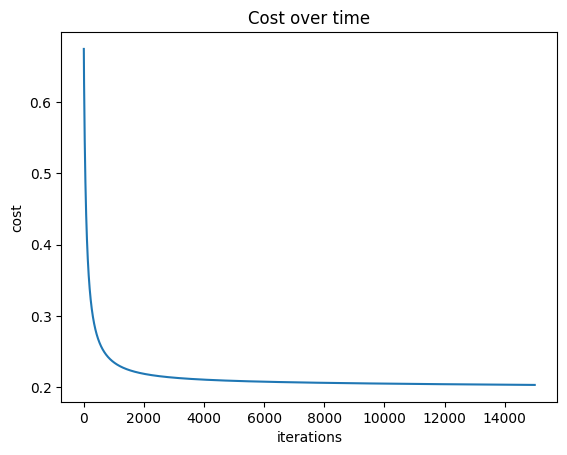

In [156]:
x_scaled=(x-np.mean(x))/np.std(x)

x_train=x_scaled[:450]
x_test=x_scaled[450:]
y_train=y[:450]
y_test=y[450:]

w=np.zeros(x_train.shape[1])
b=0
w, b, costs = gradient_descent(x_train, y_train, w, b, alpha=0.05, lambda_=1, iterations=15000)
plt.plot(costs)
plt.xlabel('iterations')
plt.ylabel('cost')
plt.title('Cost over time')
print (w,b)

In [157]:
p_train = predict(x_train, w, b)
p_test  = predict(x_test,  w, b)

print("Train accuracy: " , (np.mean(p_train == y_train) * 100))
print("Test accuracy: " , (np.mean(p_test  == y_test)  * 100))

Train accuracy:  92.0
Test accuracy:  94.11764705882352
